# Walmart sales
PROJECTS Supervised Machine Learning

## 1. Exploration et préparation du dataset

In [54]:
import pandas as pd
from summarytools import dfSummary
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score , mean_squared_error
from sklearn.linear_model import Ridge, Lasso


In [2]:
df=pd.read_csv(r"D:\Formation_Data_Engineer\Projets_certification\Bloc-3\Walmart\src\Walmart_Store_sales.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092


In [3]:
df.shape

(150, 8)

In [4]:
df.describe(include="all")

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,150.000000,132,1.360000e+02,138.000000,132.000000,136.000000,138.000000,135.000000
unique,NaN,85,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,19-10-2012,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN
mean,9.866667,NaN,1.249536e+06,0.079710,61.398106,3.320853,179.898509,7.598430
std,6.231191,NaN,6.474630e+05,0.271831,18.378901,0.478149,40.274956,1.577173
min,1.000000,NaN,2.689290e+05,0.000000,18.790000,2.514000,126.111903,5.143000
25%,4.000000,NaN,6.050757e+05,0.000000,45.587500,2.852250,131.970831,6.597500
50%,9.000000,NaN,1.261424e+06,0.000000,62.985000,3.451000,197.908893,7.470000
75%,15.750000,NaN,1.806386e+06,0.000000,76.345000,3.706250,214.934616,8.150000


Il s'agit d'un très petit dataset de 150 lignes et 8 colonnes initiales.
Le faible nombre de ligne risque d'avoir un effet négatif sur la qualité du modèle de prédiction. Cela risque de limiter la capacité du modèle à apprendre des relations robustes entre les variables et la cible "Weekly_Sales". Cela augmente également le risque d'overfitting.

Le dataset contient des données en lien avec 20 magasins Walmart.

In [5]:
dfSummary(df)

No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,Store[float64],Mean (sd) : 9.9 (6.2)min < med < max:1.0 < 9.0 < 20.0IQR (CV) : 11.8 (1.6),20 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAqRJREFUeJzt3L2O2kAYRuFvYEHmR0YIBTqalJFSUHIRudhcQgqugCJNKjokhEA4izCGNIkUKSvAM3g9r3KefmzLHO3a47Hd9Xo1IHaNug8AeMRLlRt3znXMrB2widP1en191vFAV2WhOuc6o9HoS5qmQ99t7Pf7rXPuK7Giyr+o7TRNh/P5/HUwGBzLDt7tdslisRhuNpu2mRHqf67Sf/1mZoPB4Dgej396Du889WAgi5spSCBUSCBUSCBUSCBUSLh71x8waZ9eLpeWxzjgHzdDDZm0z/M8KYri0/F4/GZmvtNTgJnd/4vqPWm/Wq2Gy+Wyez6fmwHHB5jZgxP+PpP22+2WyXoPda6PiHltRuVPpvC4OtdHxL42g1DjUuf6iKjXZhBqhOpcHxHr2gzmUSGBUCGBUCEh6mvUoihaZpY653yGN8zsErB7XoMpKfD3unm+ow01y7JWnuefp9Nps9lslroLLYqilWXZx36//6PRaOQ+++c1mHJCfi+z++c72lBPp9NLkiTd2Wx2nEwm2zJjfz8V+zCbzb6XHWvGazA+Qn6vR853tKH+0ev1vJ+K+Yz9C0/WPASc85vnm5spSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSIh+hX9dqnxRDeUR6huqflEN5RHqG6p+UQ3lEeoNvi+qFUWRmt9lQ/BXugMuWaL+QjihPlnIZUPoV7rr3HfVCPXJnvA9Au+vdNe576oRakVCvkegvO+qMI8KCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCQ+93Lfb7ZKyGz4cDomZWZZlyXq97r7neNV9qx536PhH+voFFZuzrdobIpMAAAAASUVORK5CYII="">",0(0.0%)
2,Date[object],1. nan2. 19-10-20123. 07-01-20114. 10-12-20105. 28-05-20106. 25-03-20117. 25-06-20108. 18-06-20109. 12-08-201110. 12-11-201011. other,18 (12.0%)4 (2.7%)4 (2.7%)3 (2.0%)3 (2.0%)3 (2.0%)3 (2.0%)3 (2.0%)3 (2.0%)3 (2.0%)103 (68.7%),"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAD+CAYAAAAtWHdlAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAA+BJREFUeJzt3UFqG1kARdGvIEwykRAGLUaL6MX2Imo3wqgGcchEPUjSWLHpiVU3lvqcmSeFwJcSVfxnr87n84DCpz/9Afj/EBsZsZERGxmxkREbGbGRERsZsZFZjTG+jDEernS97+fz+flK1+LOrB8fH//abDa7a1xsnuen1Wr1t+B4y3qz2ewOh8Pzdrv99p4LnU6nz9M07Y7H48MYQ2y8sh5jjO12+22/33+9wvW+XOEa3CkPCGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERmY9xo+zaO+90DWuwX1bz/P8NE3TblzhLNo8z09jjO/v/1jcIxsEMit/MovKW3c2dycW8WpdZSHFUi7WVRZSLOmtdZWFFIvwUpeM2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI3MxeDFaIUlvRq8GK2wFMfCyRi8kHFnI2PwQsbghYzBCxkvdcmIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MgYvJAxeCHjWDgZgxcyHhDI/P416iuUxVysqyyrWNKnX+uqw+Hw/DO6a/07SLjw77rq58+WVSzGAwIZsZERGxmxkREbGbGRERsZsZERGxmxkREbGbGRERuZi3UVLOnlusqyikU5Fk7GuoqMOxsZgxcyBi9kDF7IeKlLRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGxuCFjMELGcfCyRi8kHFnI2PwQsbghYzBCxkvdcmIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYx1FRnrKjI2CGSsq8i4s5GxriJjXUXGuoqMl7pkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkDF7IGLyQcSycjMELGXc2MgYvZAxeyBi8kPFSl4zYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzBCxmDFzKOhZMxeCHjAYGMr1Ey1lVkrKvIWFeR8YBARmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGxrqKjHUVGcfCyVhXkXFnI2PwQsbghYzBCxkvdcmIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MgYvJAxeCHjWDgZgxcyv9/Z+Lhu/lvnYvDCx3UPY6T1r8HLix0CH8zpdPo8TdPueDw+jDFuN7Yxfgxe9vv91z/9YfhPNz9G8lKXjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjMHLDbiX38/LwcvNH2G5Z/cwRnIs/Hbc/LFwgxcyHhDIiI2M2MiIjYzYyIiNjNjIiI2M2Mj8A5zY+DoU3NqbAAAAAElFTkSuQmCC"">",18(12.0%)
3,Weekly_Sales[float64],Mean (sd) : 1249535.8 (647463.0)min < med < max:268929.0 < 1261423.9 < 2771397.2IQR (CV) : 1201310.5 (1.9),136 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAsVJREFUeJzt3L1uGkEUQOE7YNDyo0WIBDqalJFSUPIQedg8QpB4Ago3qeiQVmgRGyOWhRRREFEkAzOMPXdyvtqznuIYc1lmzel0EiB0tffeAHCLp2s/YIxpiUjT8vr70+n0YrkWOHs1VGNMazAYfE3TtG9z8c1mszbGfCNWuLr2itpM07Q/nU5fer3e7p4L53mezOfzfpZlTREhVDi5+q9fRKTX6+2Gw+FPi+u3LNYA/2CYggqEChUIFSoQKlQgVKhAqFDhpo+n8HYc7wSKRHo3kFAD4nonUCTeu4GEGhbrO4Eicd8NJNQAOdwJFIn0biDDFFQgVKhAqFCBUKECoUIFQoUKhAoVCBUqECpUIFSoQKhQgVChAqFChaC/PaX1cUIO+06Px2Pj0fuJQbChan2ckMu+y7JMqqr6vNvtvouI7df8ohRsqKL3cULW+14ul/3FYtE+HA51X5vTKuRQRUTv44Rs9r1er6P80vMjMExBBa+vqFVVNUQkNc

Grâce à la method dfSummary de la bibliothèque Summarytools, on peut remarquer tout de suite les colonnes ayant des données manquantes :

- "Date" (18 lignes)
- "Holiday_Flag" (12 lignes)
- "Temperature" (18 lignes)
- "Fuel_Price" (14 lignes)
- "CPI" (12 lignes)
- "Unemployment" (15 lignes)

- "Weekly_Sales" : La colonne qui nous servira de cible pour l'entrainement du modèle, est aussi concernée avec 14 lignes manquantes ==> Nous allons immédiatement procéder à la suppression des lignes vides pour cette colonne.

Pour les autres colonnes, nous allons proposer de remplacer les valeurs manquantes, si possible.

In [6]:
target = "Weekly_Sales"

In [7]:
df.dropna(subset = [target], inplace = True)
df.shape

(136, 8)

Il est impossible d'inférer une date pour les lignes où celle-ci est manquante. Nous supprimons également les lignes concernées

In [8]:
df.dropna(subset = ["Date"], inplace = True)
df.shape

(118, 8)

Nous observons des lignes vides dans "Holiday_Flag". Avant de décider si nous remplaçons les valeurs vides ou si nous supprimons les lignes, analysons la colonne.

In [9]:
df[df["Holiday_Flag"].isna()][["Date","Holiday_Flag","Weekly_Sales"]].sort_values("Date")

,Date,Holiday_Flag,Weekly_Sales
48,05-08-2011,NaN,1624383.75
136,08-07-2011,NaN,2066541.86
90,09-07-2010,NaN,485389.15
0,18-02-2011,NaN,1572117.54
118,18-06-2010,NaN,513073.87
53,25-03-2011,NaN,1879451.23
43,26-08-2011,NaN,629994.47
73,27-08-2010,NaN,1449142.92
15,30-04-2010,NaN,1498080.16


Ces dates ne correspondent à aucune semaine durant laquelle il y aurait un jour spécifique aux USA. Nous pouvons donc remplacer les NaN par 0

In [10]:
df["Holiday_Flag"] = df["Holiday_Flag"].fillna(0).astype(int)

Maintenant, nous allons exploser la colonne "Date" en "Année"/"Mois"/"jour" et nous ajoutons 2 autres colonnes pour aider le modèle à saisonnaliser les prédictions : "semaine_annee" et "trimestre"

In [11]:
# Conversion de la colonne Date
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Tri par magasin puis par date
df = df.sort_values(["Store", "Date"]).reset_index(drop=True)

In [12]:
df['Year'] = df['Date'].dt.year    
df['Month'] = df['Date'].dt.month
#df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
#df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)
df["Week"] = df["Date"].dt.isocalendar().week
#df["Week_sin"] = np.sin(2 * np.pi * df["Week"] / 52)
#df["Week_cos"] = np.cos(2 * np.pi * df["Week"] / 52)
df=df.drop(columns=["Date"])
df

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week
0,1.0,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6
1,1.0,1494251.50,0,74.78,2.854,210.337426,7.808,2010,5,19
2,1.0,1449142.92,0,85.22,2.619,211.567306,7.787,2010,8,34
3,1.0,1466046.67,0,NaN,3.786,215.503788,7.682,2011,5,21
4,1.0,1624383.75,0,91.65,3.684,215.544618,7.962,2011,8,31
...,...,...,...,...,...,...,...,...,...,...
113,19.0,1468350.36,0,NaN,3.722,138.162900,8.150,2012,6,25
114,20.0,1973135.87,0,75.17,2.808,204.567546,7.856,2010,6,25
115,20.0,1789687.65,0,69.37,NaN,NaN,7.527,2010,9,38
116,20.0,1799737.79,1,28.85,3.179,204.643227,7.484,2010,12,52


In [13]:
df.shape

(118, 10)

Nettoyage des outliers et remplacement des valeurs manquantes

Nous supprimons les outliers pour les colonnes "Temperature", "Fuel_Price","CPI" et "Unemployment" avant de travailler sur les NaN pour éviter un biais lié à ces outliers.

In [14]:
def compute_bounds(df, cols):
    bounds = {}
    for col in cols:
        mean = df[col].mean()
        std = df[col].std()
        bounds[col] = (mean - 3 * std, mean + 3 * std)
    return bounds

def remove_outliers(df, bounds):
    mask = pd.Series(True, index=df.index)
    for col, (lower, upper) in bounds.items():
        mask &= df[col].isna() | df[col].between(lower, upper)
    return df[mask].copy()

cols_outliers = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]
bounds = compute_bounds(df, cols_outliers)
df = remove_outliers(df, bounds)

Pour la colonne Temperature, nous allons combiner la moyenne des températures à la même période les années précédentes et celle pour les semaines entourant la ligne concernée. Si nous ne pouvons calculer qu'une des deux données, nous utilisons celle disponible, sinon nous faisons une moyenne des deux.

Pour Fuel Price, CPI et Unemployment, nous allons faire une interpolation linéaire et calculer une valeur théorique pour chaque ligne vide

In [15]:
def estimate_temperature(group):
    group = group.copy()

    local_mean = group["Temperature"].rolling(
        window=3,
        center=True,
        min_periods=1
    ).mean()

    seasonal_mean = group.groupby("Week")["Temperature"].transform("mean")

    estimate = pd.concat([local_mean, seasonal_mean], axis=1).mean(axis=1)

    group["Temperature"] = group["Temperature"].fillna(estimate)

    return group

df = df.groupby("Store", group_keys=False).apply(estimate_temperature)

C:\Users\Vartkirl\AppData\Local\Temp\ipykernel_11660\1976849436.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Store", group_keys=False).apply(estimate_temperature)


In [16]:
cols_interp = ["Fuel_Price", "CPI", "Unemployment"]

df[cols_interp] = (
    df.groupby("Store")[cols_interp]
    .apply(lambda x: x.interpolate(method="linear", limit_direction="both"))
    .reset_index(level=0, drop=True)
)

Enfin, nous allons modifier le type des colonnes catégorielles "Store" et "Holiday_Flag" en "Category".

In [17]:
df["Store"] = df["Store"].astype("category")
df["Holiday_Flag"] = df["Holiday_Flag"].astype("category")

Enfin, vérifions s'il y a des lignes en doublon

In [68]:
df.duplicated().sum()

np.int64(0)

Aucun doublon repéré

## 2. EDA

Verification de la distribution des variables

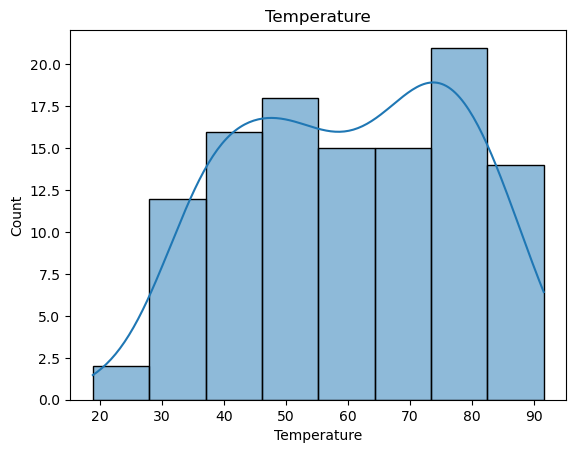

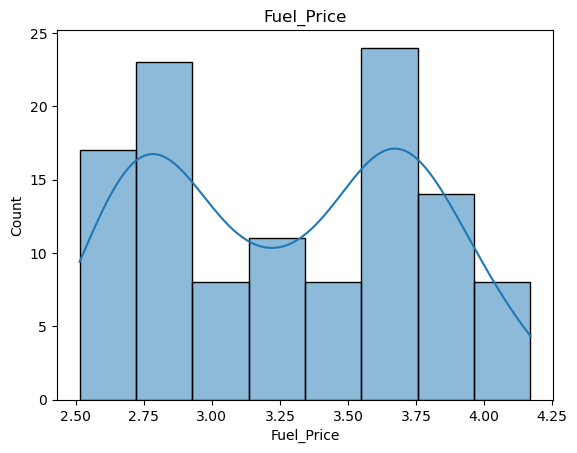

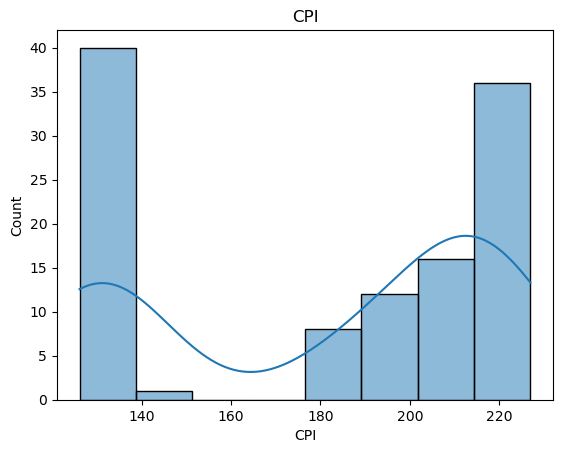

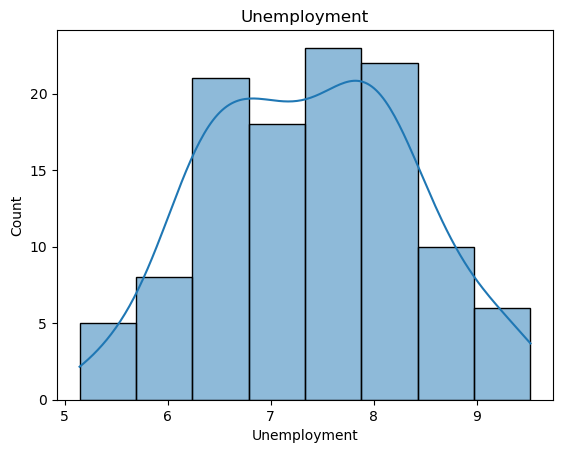

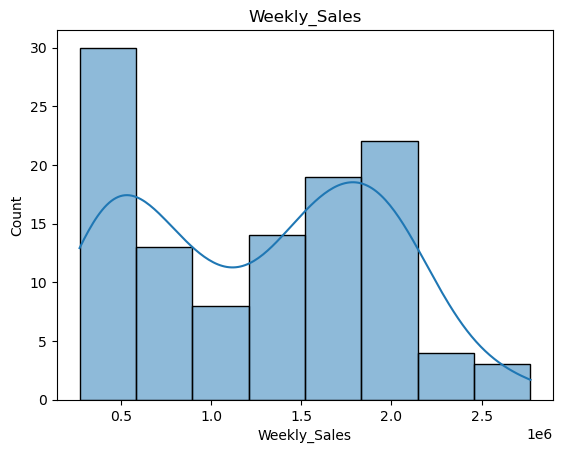

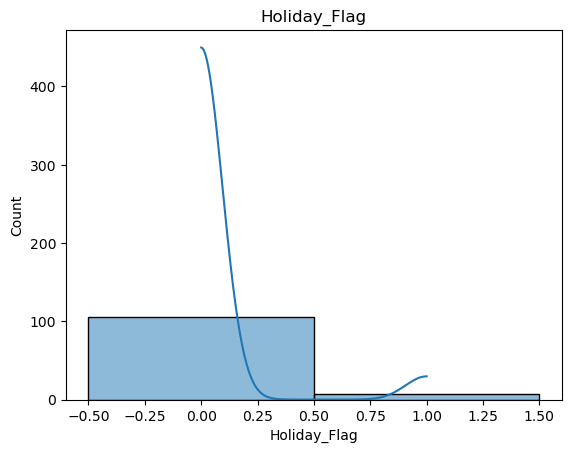

In [19]:
cols = ["Temperature","Fuel_Price","CPI","Unemployment","Weekly_Sales","Holiday_Flag"]

for col in cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

Distribution de la variable cible

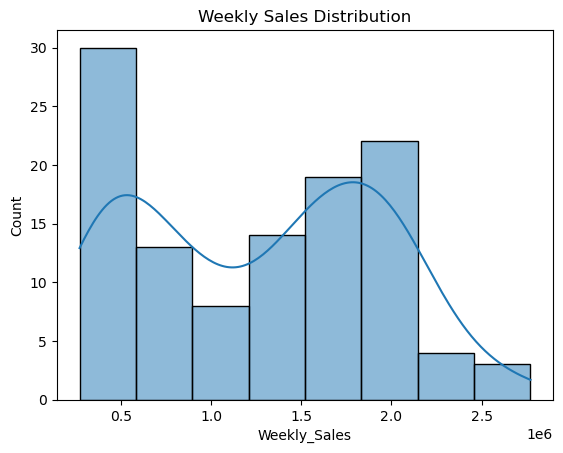

In [20]:
sns.histplot(df[target], kde=True)
plt.title("Weekly Sales Distribution")
plt.show()

Matrice de corrélation

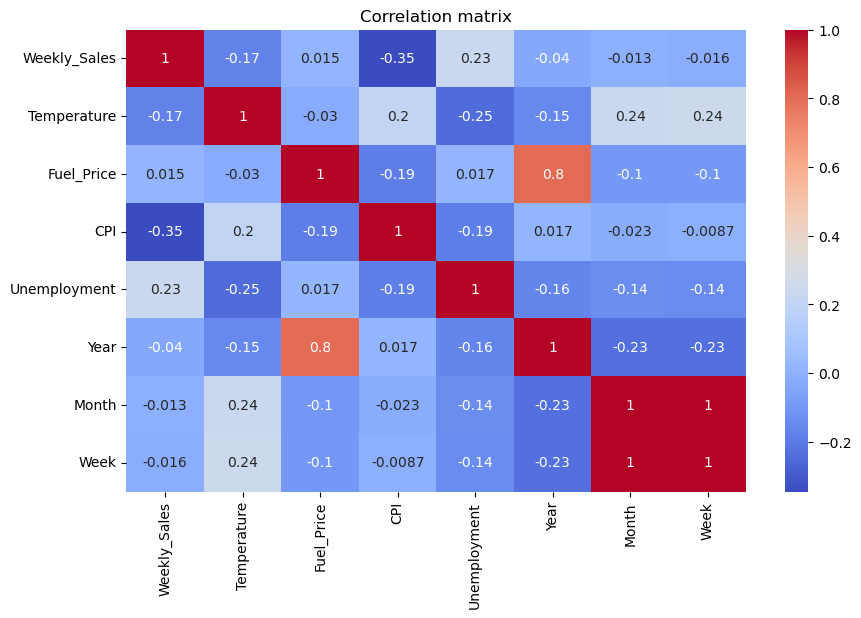

In [21]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()


Aucune variable n'a de corrélation vraiment forte avec notre variable cible "Weekly_Sales".

    - Cela peut signifier :
        - que les niveaux de ventes dépendent de plusieurs facteurs combinés
        - que certaines variables utiles sont absentes de ce dataset
        - que certaines relations ne sont pas linéaires

    - La corrélation la plus forte qui ressort pour "Weekly_Sales" est  : 
        - "CPI" qui a la corrélation la plus forte mais négative (-0.42) ==> celà indique une relation inverse : lorsque le CPI augmente dans le dataset, les ventes hebdomadaires ont tendance à être plus faibles.

On remarque également une absence de lien entre niveau des ventes et évolution des températures : 

    - correlation "Weekly_Sales" * "Temperature" = -0,084 : c'est très faible.

Enfin, il y a une très forte corrélation entre "Fuel_Price" et "année" : le niveau de "Fuel_Price" augmente régulièrement avec le temps.

Analyse du lien entre "Weekly_Sales" et "Store"

C:\Users\Vartkirl\AppData\Local\Temp\ipykernel_11660\133610441.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  store_sales = df.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False)


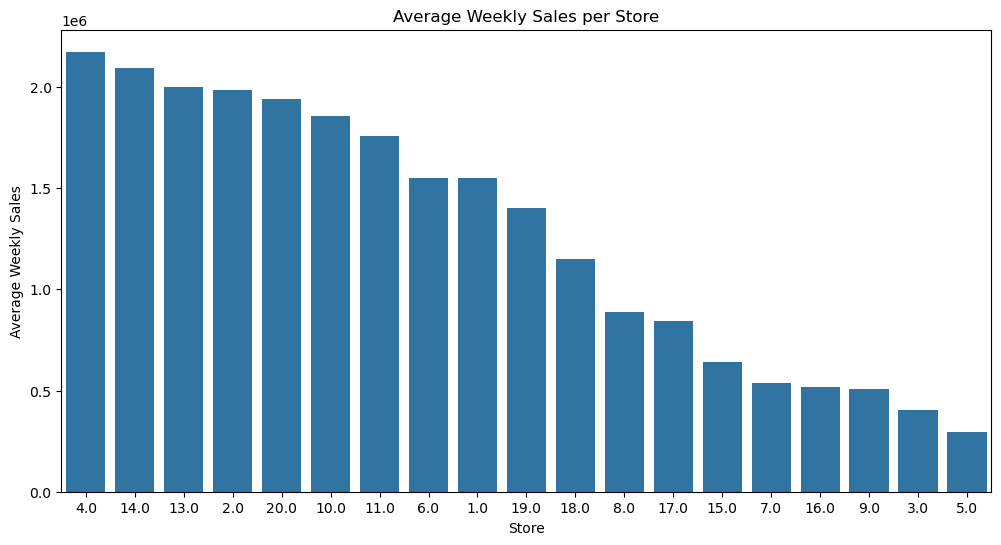

In [22]:
store_sales = df.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    x=store_sales.index,
    y=store_sales.values,
    order=store_sales.index
)

plt.title("Average Weekly Sales per Store")
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")

plt.show()

In [23]:
df.groupby("Store")["Weekly_Sales"].describe()

C:\Users\Vartkirl\AppData\Local\Temp\ipykernel_11660\3158284433.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Store")["Weekly_Sales"].describe()


,count,mean,std,min,25%,50%,75%,max
Store,,,,,,,,
1.0,8.0,1.550101e+06,86549.217406,1449142.92,1.487200e+06,1523776.235,1.628777e+06,1677472.78
2.0,6.0,1.982229e+06,255187.952155,1758050.79,1.815091e+06,1889307.720,2.072542e+06,2432736.52
3.0,10.0,4.033533e+05,32091.942673,364076.85,3.748212e+05,401090.685,4.232593e+05,461622.22
4.0,6.0,2.173759e+06,326041.867113,1857533.70,2.015317e+06,2051386.625,2.243514e+06,2771397.17
5.0,7.0,2.943988e+05,17181.425292,268929.03,2.830361e+05,298697.840,3.068670e+05,313358.15
6.0,6.0,1.551124e+06,86249.338274,1420405.41,1.506637e+06,1552213.160,1.622549e+06,1644470.66
7.0,7.0,5.366644e+05,76491.857613,414094.05,4.950399e+05,561145.140,5.806687e+05,629994.47
8.0,6.0,8.887541e+05,56255.818147,836707.85,8.576811e+05,874576.470,8.935041e+05,994801.40
9.0,4.0,5.068874e+05,14982.539601,485389.15,5.032947e+05,511168.575,5.147612e+05,519823.30


On remarque une forte variation du niveau de vente moyen selon le magasin. Cette différence entre magasins peut s'expliquer par des facteurs non présents dans le dataset comme la taille du magasin, son emplacement, etc. .

Il y a toutefois une limite à l'analyse du lien "weekly_Sales"*"Store" : le faible nombre d'observations par magasin qui varie entre 1 et 8.

Analyse de la saisonnalité

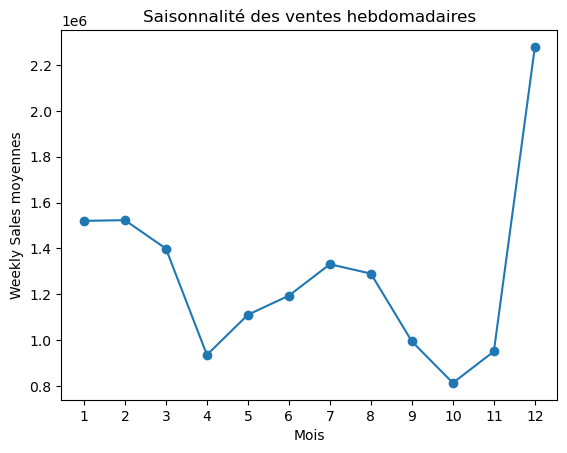

In [24]:
seasonality = df.groupby("Month")["Weekly_Sales"].agg(
    mean_sales="mean",
    n_obs="count"
).reset_index()

plt.figure()

plt.plot(seasonality["Month"], seasonality["mean_sales"], marker="o")

plt.xlabel("Mois")
plt.ylabel("Weekly Sales moyennes")
plt.title("Saisonnalité des ventes hebdomadaires")

plt.xticks(range(1,13))

plt.show()

In [25]:
print(seasonality[["Month", "n_obs"]])

    Month  n_obs
0       1      5
1       2     12
2       3     10
3       4      9
4       5     12
5       6     14
6       7     12
7       8     10
8       9      6
9      10      8
10     11      8
11     12      7


## 3. Modélisation

### 3.1 Modèle Baseline Regression linéaire

In [26]:
Y = df[target]
X = df.drop(columns=[target]).copy()

numeric_features = ["Temperature", "Fuel_Price", "CPI", "Unemployment", "Year"]
categorical_features = ["Store", "Holiday_Flag", "Month", "Week"]

In [27]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(
    steps=[
    ("encoder", OneHotEncoder(drop="first",handle_unknown="ignore"))
    ])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [28]:
X_train, X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3,random_state = 42)

Les valeurs manquantes résiduelles, si certaines subsistent après le nettoyage métier, seront imputées via le SimpleImputer intégré au pipeline de transformation.

In [29]:
model_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [30]:
model_baseline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [31]:
Y_train_pred_baseline = model_baseline.predict(X_train)
Y_test_pred_baseline = model_baseline.predict(X_test)

c:\Users\Vartkirl\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [32]:
coef = model_baseline.named_steps["regressor"].coef_
(coef != 0).sum()

np.int64(73)

In [33]:
print("R2 score sur train set :", r2_score(Y_train, Y_train_pred_baseline))
print("R2 score sur test set :", r2_score(Y_test, Y_test_pred_baseline))

print("Train RMSE :", np.sqrt(mean_squared_error(Y_train, Y_train_pred_baseline)))
print("Test RMSE :", np.sqrt(mean_squared_error(Y_test, Y_test_pred_baseline)))

R2 score sur train set : 0.9968747324800743
R2 score sur test set : 0.9385449511683093
Train RMSE : 37224.27323948318
Test RMSE : 168971.207244464


A la lecture des résultats, on remarque un R2 significativement plus faible sur le jeu test par rapport au jeu d'entrainement. Nous avons affaire à un cas d'overfitting du modèle sur le jeu d'entrainement qui ne parvient pas à généraliser convenablement sur le jeu test.

Nous allons tout d'abord analyser les coefficients afin de comprendre quelles variables influencent les prédictions et d’identifier d’éventuelles sources de complexité ou de redondance.

### 3.2 Analyse des coefficients du modèle baseline

In [35]:
coefs = model_baseline.named_steps["regressor"].coef_
feature_names = preprocessor.get_feature_names_out()
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
})

coef_df.sort_values("coefficient", ascending=False)

,feature,coefficient
13,cat__Store_10.0,3.669442e+06
15,cat__Store_13.0,3.564283e+06
7,cat__Store_4.0,3.482961e+06
21,cat__Store_19.0,3.001608e+06
20,cat__Store_18.0,2.727173e+06
...,...,...
18,cat__Store_16.0,-2.234828e+05
11,cat__Store_8.0,-9.441292e+05
8,cat__Store_5.0,-1.337761e+06
12,cat__Store_9.0,-1.362286e+06


<Axes: ylabel='feature'>

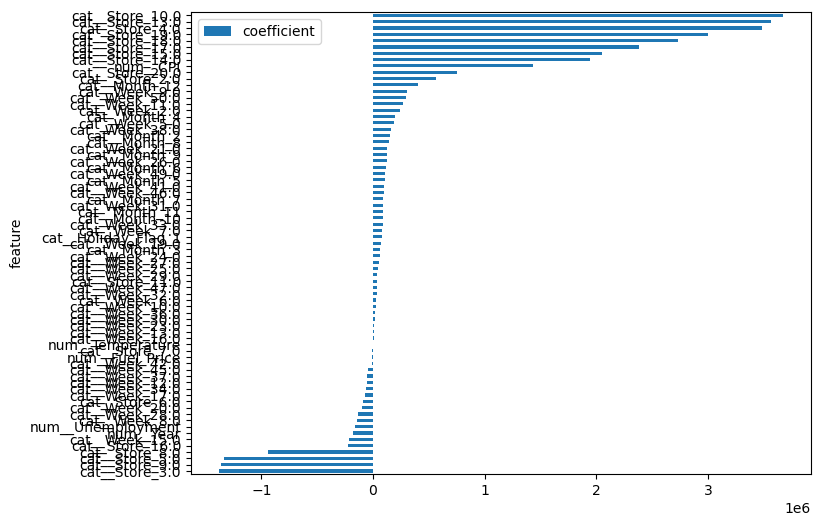

In [36]:
coef_df.sort_values("coefficient").plot(
    x="feature",
    y="coefficient",
    kind="barh",
    figsize=(8,6)
)

La lecture des coefficients nous informe sur plusieurs points :

    - "Store" : Le magasin est un facteur déterminant pour le volume de ventes. C'est le facteur de variation le plus important parmis les données à notre disposition.
    - "CPI" : L'indice des prix à la consommation a un fort impact sur les volumes de ventes. Il semble cependant avoir un impact positif sur les ventes à mesure qu'il croit, ce qui est contre-intuitif. Nous devons Explorer le lien CPI/Weekly sales.
    - "Month_sin" , "Week_sin" : il semble y avoir un effet saisonnier à confirmer.
    - "Temperature" : Les températures plus basses semblent favoriser les volumes de ventes plus importants. Il faut explorer ce point et voir si ce n'est pas une variable confondante.

#### 3.2.1 Exploration du lien CPI * Weekly Sales

In [37]:
df[["CPI","Weekly_Sales","Year"]].corr()

,CPI,Weekly_Sales,Year
CPI,1.000000,-0.345483,0.016766
Weekly_Sales,-0.345483,1.000000,-0.040318
Year,0.016766,-0.040318,1.000000


Il y a bien une corrélation négative entre "Weekly_sales" et "CPI" ce qui signifie que, sans contrôle des autres variables, en moyenne, les "Weekly_sales" diminue quand "PCI" augmente.

Nous devons étudier les colinéarités entre les variables. Nous allons commencer la variable qui a le plus d'impact sur la prédiction : "Store"

In [38]:
df.groupby("Store").apply(lambda x: x["CPI"].corr(x["Weekly_Sales"]))

C:\Users\Vartkirl\AppData\Local\Temp\ipykernel_11660\1792133688.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Store").apply(lambda x: x["CPI"].corr(x["Weekly_Sales"]))
c:\Users\Vartkirl\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\Vartkirl\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\Vartkirl\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
C:\Users\Vartkirl\AppData\Local\Temp\ipykernel_11660\1792133688.py:1: FutureWarning: DataFrameGroupBy.apply ope

Store
1.0     0.227447
2.0    -0.150478
3.0     0.128970
4.0     0.450666
5.0     0.532947
6.0    -0.158452
7.0     0.064650
8.0    -0.209209
9.0     0.878461
10.0    0.620470
11.0         NaN
13.0   -0.406748
14.0   -0.339855
15.0   -0.665574
16.0   -0.441664
17.0    0.723313
18.0   -0.407222
19.0   -0.225398
20.0    0.898076
dtype: float64

Les corrélations intra-magasin sont hétérogènes, avec des signes parfois opposés. Cela indique que la relation entre CPI et ventes varie selon le magasin.

Reprenons le pipeline sans intégrer la variable "Store"

c:\Users\Vartkirl\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


<Axes: ylabel='feature'>

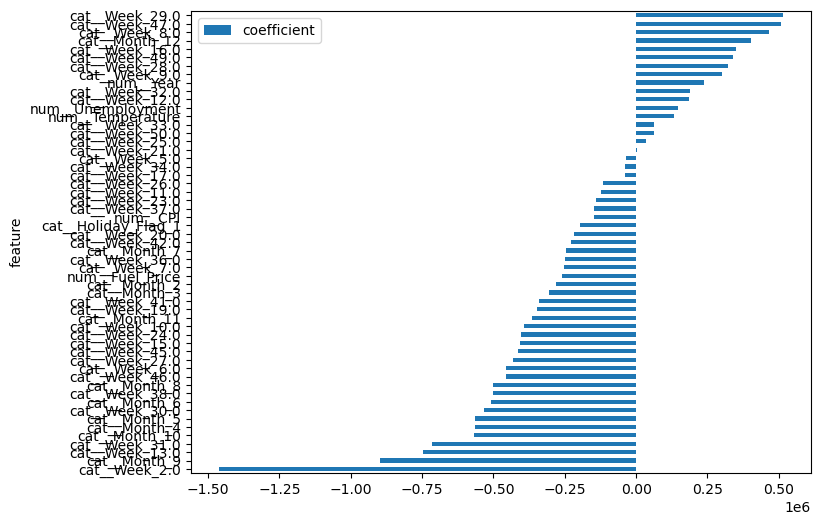

In [39]:
Y_analyse = df[target]
X_analyse = df.drop(columns=[target]).copy()
#, "Month", "Week"
#,"Month_sin","Month_cos","Week_sin","Week_cos"
numeric_features_analyse = ["Temperature","Fuel_Price","CPI","Unemployment","Year"]
categorical_features_analyse = ["Holiday_Flag", "Month", "Week"]

X_train_analyse, X_test_analyse, Y_train_analyse, Y_test_analyse = train_test_split(X_analyse, Y_analyse, test_size=0.3, random_state=42)

preprocessor_analyse = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features_analyse),
        ("cat", Pipeline([
            ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
        ]), categorical_features_analyse)
    ]
)

X_train_analyse = preprocessor_analyse.fit_transform(X_train_analyse)
X_test_analyse = preprocessor_analyse.transform(X_test_analyse)

model_analyse = LinearRegression()
model_analyse.fit(X_train_analyse, Y_train_analyse)

coef_df_CPI = pd.DataFrame({
    "feature": preprocessor_analyse.get_feature_names_out(),
    "coefficient": model_analyse.coef_
})

coef_df_CPI.sort_values("coefficient").plot(
    x="feature",
    y="coefficient",
    kind="barh",
    figsize=(8, 6)
)

Le coefficient de "CPI" redevient négatif.

L'inversion de signe du coefficient de "CPI" est directement lié à "Store".
Sans contrôle du magasin, CPI présente une corrélation négative avec les ventes. Cependant, une fois l’effet du magasin contrôlé, le coefficient devient positif. Ce phénomène s’explique par un effet de composition, où les différences structurelles entre magasins masquent la relation intra-magasin.

#### 3.2.2 Exploration de la saisonnalité

In [40]:
coef_series = pd.Series(
    model_baseline.named_steps["regressor"].coef_,
    index=preprocessor.get_feature_names_out()
)

month_coefs = coef_series[coef_series.index.str.contains("Month", case=False, na=False)]

month_effect_df = (
    month_coefs
    .rename_axis("feature")
    .reset_index(name="coefficient")
)

# extraire le numéro du mois, avec ou sans .0
month_effect_df["Month"] = (
    month_effect_df["feature"]
    .str.extract(r"Month_(\d+(?:\.0)?)", expand=False)
)

print(month_effect_df)  # pour vérifier les noms extraits

month_effect_df = month_effect_df.dropna(subset=["Month"]).copy()
month_effect_df["Month"] = month_effect_df["Month"].astype(float).astype(int)

# ajouter le mois de référence si drop='first'
if 1 not in month_effect_df["Month"].values:
    month_effect_df = pd.concat([
        pd.DataFrame({"feature": ["reference"], "coefficient": [0], "Month": [1]}),
        month_effect_df
    ], ignore_index=True)

month_effect_df = month_effect_df.sort_values("Month")
month_effect_df

          feature    coefficient Month
0    cat__Month_2  149798.825250     2
1    cat__Month_3   65850.038871     3
2    cat__Month_4  196254.320602     4
3    cat__Month_5  103465.261662     5
4    cat__Month_6  118380.215593     6
5    cat__Month_7   92931.520398     7
6    cat__Month_8  145228.009240     8
7    cat__Month_9  122143.734360     9
8   cat__Month_10   86552.368791    10
9   cat__Month_11   86620.958080    11
10  cat__Month_12  402029.079662    12


,feature,coefficient,Month
0,reference,0.000000,1
1,cat__Month_2,149798.825250,2
2,cat__Month_3,65850.038871,3
3,cat__Month_4,196254.320602,4
4,cat__Month_5,103465.261662,5
5,cat__Month_6,118380.215593,6
6,cat__Month_7,92931.520398,7
7,cat__Month_8,145228.009240,8
8,cat__Month_9,122143.734360,9
9,cat__Month_10,86552.368791,10


<Axes: title={'center': 'Effet des mois dans le modèle'}, xlabel='Month'>

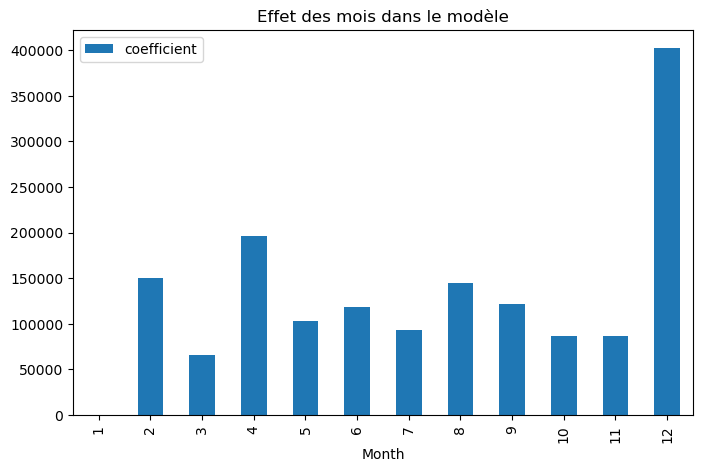

In [41]:
month_effect_df.plot(
    x="Month",
    y="coefficient",
    kind="bar",
    figsize=(8, 5),
    title="Effet des mois dans le modèle"
)

L'analyse des coefficients de la variable "Month" montre une saisonnalité marquée :

    - Comme nous faisons un drop = "first", les valeurs des coefficients affichés sont des écarts au 1er mois ==> Les coefficients de tous les mois sont positifs donc Janvier est un creux au niveau des ventes.
    - Le printemps et l'été sont des périodes de ventes plus élevées mais diffuses sur la période.
    - Le mois de décembre a un coefficient très élevé et constitue un pic annuel

In [42]:
week_coefs = coef_series[coef_series.index.str.contains("Week", case=False, na=False)]

week_effect_df = (
    week_coefs
    .rename_axis("feature")
    .reset_index(name="coefficient")
)

week_effect_df["Week"] = (
    week_effect_df["feature"]
    .str.extract(r"Week_(\d+(?:\.0)?)", expand=False)
)

print(week_effect_df)  # contrôle

week_effect_df = week_effect_df.dropna(subset=["Week"]).copy()
week_effect_df["Week"] = week_effect_df["Week"].astype(float).astype(int)

if 1 not in week_effect_df["Week"].values:
    week_effect_df = pd.concat([
        pd.DataFrame({"feature": ["reference"], "coefficient": [0], "Week": [1]}),
        week_effect_df
    ], ignore_index=True)

week_effect_df = week_effect_df.sort_values("Week")
week_effect_df

           feature    coefficient  Week
0    cat__Week_2.0  244666.962698   2.0
1    cat__Week_5.0  185561.507998   5.0
2    cat__Week_6.0   25586.478617   6.0
3    cat__Week_7.0   80379.486491   7.0
4    cat__Week_8.0 -141728.647856   8.0
5    cat__Week_9.0  304979.946928   9.0
6   cat__Week_10.0   22297.907491  10.0
7   cat__Week_11.0  267838.446765  11.0
8   cat__Week_12.0  -56341.437033  12.0
9   cat__Week_13.0    8024.598472  13.0
10  cat__Week_15.0 -218582.950328  15.0
11  cat__Week_16.0    6192.412319  16.0
12  cat__Week_17.0  -72304.565141  17.0
13  cat__Week_19.0   73972.289608  19.0
14  cat__Week_20.0  -98045.404841  20.0
15  cat__Week_21.0  127538.376894  21.0
16  cat__Week_23.0   10400.201184  23.0
17  cat__Week_24.0   63395.396762  24.0
18  cat__Week_25.0   44584.617647  25.0
19  cat__Week_26.0  121483.641683  26.0
20  cat__Week_27.0   51329.769030  27.0
21  cat__Week_28.0 -131185.799945  28.0
22  cat__Week_29.0   38393.025727  29.0
23  cat__Week_30.0   12910.883902  30.0


,feature,coefficient,Week
0,reference,0.000000,1
1,cat__Week_2.0,244666.962698,2
2,cat__Week_5.0,185561.507998,5
3,cat__Week_6.0,25586.478617,6
4,cat__Week_7.0,80379.486491,7
5,cat__Week_8.0,-141728.647856,8
6,cat__Week_9.0,304979.946928,9
7,cat__Week_10.0,22297.907491,10
8,cat__Week_11.0,267838.446765,11
9,cat__Week_12.0,-56341.437033,12


<Axes: title={'center': 'Effet des semaines dans le modèle'}, xlabel='Week'>

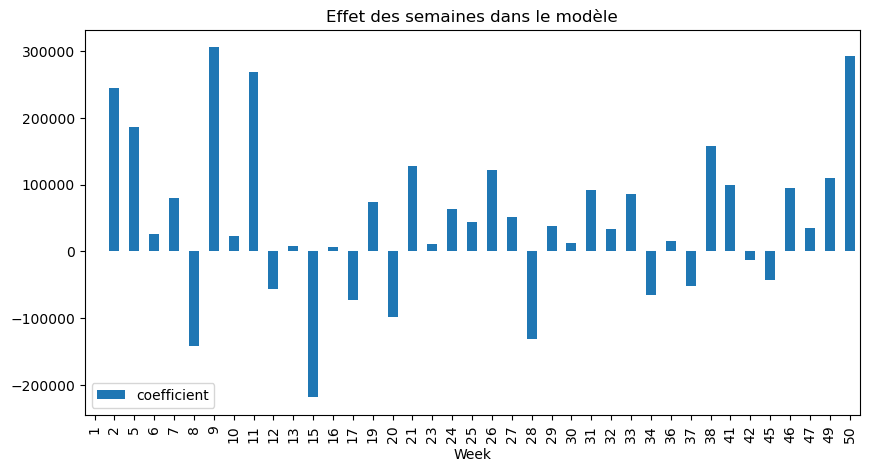

In [43]:
week_effect_df.plot(
    x="Week",
    y="coefficient",
    kind="bar",
    figsize=(10, 5),
    title="Effet des semaines dans le modèle"
)

l'analyse des semaines est plus délicate. Notre dataframe d'entrainement contient 113 lignes. Pour 52 semaines dans une année, cela fait peu d'observations par semaine. Cette situation empêche de proposer des hypothèses fiables, sauf pour les semaines de fin d'année qui correspondent au mois de Décembre où l'effet fêtes de fin d'année est visible.

In [44]:
coef_holiday = coef_df.loc[
    coef_df["feature"].str.contains("Holiday"),
    "coefficient"
].values[0]

holiday_effect_df = pd.DataFrame({
    "Holiday_Flag": [0, 1],
    "Contribution_modele": [0, coef_holiday]
})

holiday_effect_df

,Holiday_Flag,Contribution_modele
0,0,0.000000
1,1,75950.285308


In [45]:
(df["Holiday_Flag"] == 1).sum()

np.int64(7)

In [46]:
df.groupby("Store")["Holiday_Flag"].apply(lambda x: (x == 1).sum())

C:\Users\Vartkirl\AppData\Local\Temp\ipykernel_11660\1089652514.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Store")["Holiday_Flag"].apply(lambda x: (x == 1).sum())


Store
1.0     1
2.0     0
3.0     0
4.0     0
5.0     0
6.0     0
7.0     2
8.0     1
9.0     0
10.0    0
11.0    1
13.0    0
14.0    1
15.0    0
16.0    0
17.0    0
18.0    0
19.0    0
20.0    1
Name: Holiday_Flag, dtype: int64

L'impact de "Holiday" est bien visible. Le coefficient de cette variable lorsqu'elle est à 1 (semaines durant lesquelles il y a un jour spécial) est de + 76 000.

Cependant, il faut rester très prudent sur cette hypothèse car il n'y a que 7 observations de Holiday = 1 dans les 113 lignes du dataframe final.

#### 3.2.3 Exploration de l'influence de "Temperature"

<Axes: xlabel='Temperature', ylabel='Weekly_Sales'>

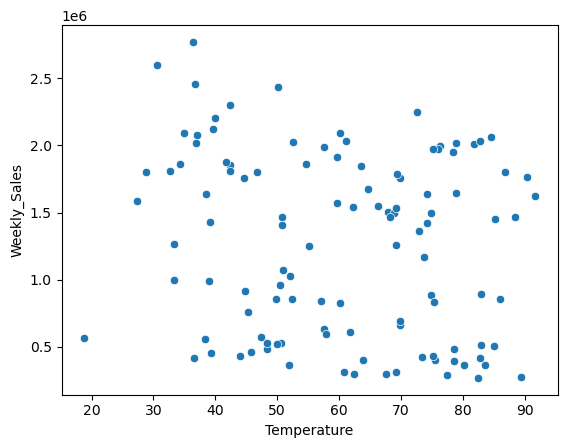

In [47]:
sns.scatterplot(x="Temperature", y="Weekly_Sales", data=df)

<Axes: xlabel='Temperature', ylabel='Weekly_Sales'>

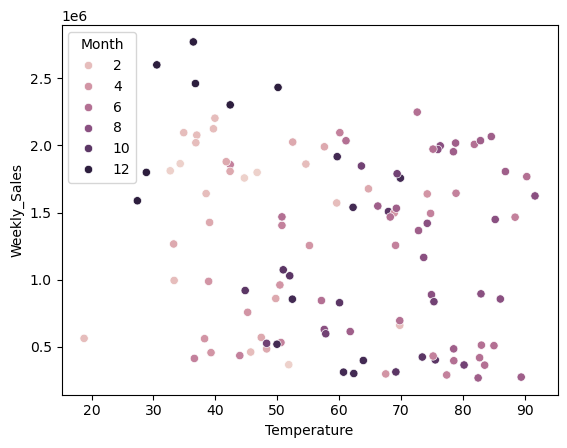

In [48]:
sns.scatterplot(data=df, x="Temperature", y="Weekly_Sales", hue="Month")

Lorsqu’on intègre le mois dans l’analyse du lien entre Temperature et Weekly_Sales, on observe que le mois de décembre concentre à la fois des températures plus basses et des niveaux de ventes élevés. A l'inverse, d'autres mois comme février, qui a également des températures froides, ont un niveau de vente beaucoup plus dispersé sans relation claire avec la température.

Il semble donc que la relation observée entre  Weekly_sales et Temperature est en grande partie liée à un effet de confusion lié à  la saisonnalité des ventes. 

Le modèle baseline s'appuie majoritairement sur quelques variables de saisonnalité "Month" et "Week" ainsi que d'autres variables structurelles telles que "Store. D’autres variables, telles que CPI ou Temperature, présentent une contribution plus faible ou potentiellement indirecte.

Cette distribution des coefficients suggère que le modèle utilise un grand nombre de variables dont certaines apportent peu d’information pertinente ou capturent des effets redondants. Cette complexité excessive peut contribuer au phénomène d’overfitting observé précédemment.

Nous allons mettre en place une régluarisation du modèle en tentant de réduire l'amplitude des coefficients (Ridge) ou d'en supprimer certains (Lasso) afin de limiter l'overfitting et d'améliorer la capacité du modèle à généraliser. 

### 3.3 Régularisation du modèle

#### 3.3.1 Ridge

In [69]:
model_Ridge = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=0.349))
])

model_Ridge.fit(X_train, Y_train)

Y_train_pred_Ridge = model_Ridge.predict(X_train)
Y_test_pred_Ridge = model_Ridge.predict(X_test)

print("R2 score sur train set :", r2_score(Y_train, Y_train_pred_Ridge))
print("R2 score sur test set :", r2_score(Y_test, Y_test_pred_Ridge))

print("Train RMSE :", np.sqrt(mean_squared_error(Y_train, Y_train_pred_Ridge)))
print("Test RMSE :", np.sqrt(mean_squared_error(Y_test, Y_test_pred_Ridge)))

R2 score sur train set : 0.9822304616027719
R2 score sur test set : 0.9530631927907656
Train RMSE : 88760.6964639872
Test RMSE : 147669.46281263753


c:\Users\Vartkirl\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [50]:
coef = model_Ridge.named_steps["regressor"].coef_
(coef != 0).sum()

np.int64(73)

### 3.3.2 Lasso

In [70]:
model_Lasso = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Lasso(alpha=2388))
])

model_Lasso.fit(X_train, Y_train)

Y_train_pred_Lasso = model_Lasso.predict(X_train)
Y_test_pred_Lasso = model_Lasso.predict(X_test)

print("R2 score sur train set :", r2_score(Y_train, Y_train_pred_Lasso))
print("R2 score sur test set :", r2_score(Y_test, Y_test_pred_Lasso))

print("Train RMSE :", np.sqrt(mean_squared_error(Y_train, Y_train_pred_Lasso)))
print("Test RMSE :", np.sqrt(mean_squared_error(Y_test, Y_test_pred_Lasso)))

R2 score sur train set : 0.9816380332080854
R2 score sur test set : 0.9600504498037716
Train RMSE : 90228.1861758982
Test RMSE : 136235.3682021089


c:\Users\Vartkirl\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [52]:
coef = model_Lasso.named_steps["regressor"].coef_
(coef != 0).sum()

np.int64(29)

In [ ]:
comparison_df = pd.DataFrame({
    "model": ["Baseline", "Ridge", "Lasso",],
    "R2_train": [
        r2_score(Y_train, Y_train_pred_baseline),
        r2_score(Y_train, Y_train_pred_Ridge),
        r2_score(Y_train, Y_train_pred_Lasso)
    ],
    "R2_test": [
        r2_score(Y_test, Y_test_pred_baseline),
        r2_score(Y_test, Y_test_pred_Ridge),
        r2_score(Y_test, Y_test_pred_Lasso)
    ],
    "RMSE_train": [
        np.sqrt(mean_squared_error(Y_train, Y_train_pred_baseline)),
        np.sqrt(mean_squared_error(Y_train, Y_train_pred_Ridge)),
        np.sqrt(mean_squared_error(Y_train, Y_train_pred_Lasso))
    ],
    "RMSE_test": [
        np.sqrt(mean_squared_error(Y_test, Y_test_pred_baseline)),
        np.sqrt(mean_squared_error(Y_test, Y_test_pred_Ridge)),
        np.sqrt(mean_squared_error(Y_test, Y_test_pred_Lasso))
    ]
})

comparison_df

,model,R2_train,R2_test,RMSE_train,RMSE_test
0,Baseline,0.996875,0.938545,37224.273239,168971.207244
1,Ridge,0.982230,0.953063,88760.696464,147669.462813
2,Lasso,0.981638,0.960050,90228.186176,136235.368202


Avec un R2 sur le jeu "Train" quasi parfait et un baisse significative du R2 sur le jeu "Test" combinée à une RMSE élevée, le modèle baseline est clairement en overfitting

==> La régularisation du modèle est justifiée.

Ridge :

L'utilisation d'une régularisation Ridge réduit le R2 du jeu "Train" en améliorant celui du jeu "Test" et en réduisant la RMSE du jeu "Test". La réduction de l'amplitude des coefficients permet de réduire la variance et agit positivement sur l'overfitting en permettant une meilleure généralisation.

Lasso :

L'utilisation d'une régularisation Lasso améliore encore le résultat du modèle. le R2 du jeu "Test" s'améliore encore par rapport à l'utilisation du Ridge et la RMSE du jeu "Test" est encore réduite. ==> La simplification du modèle via la suppression des variables inutiles a un effet encore plus marqué que la limitation de l'amplitude des coefficients.


Une régularisation via Lasso semble, ici, la solution la plus favorable au modèle.

Nous allons maintenant optimiser notre modèle Lasso à l’aide d’un GridSearchCV, qui évalue différentes valeurs de l’hyperparamètre alpha en utilisant une validation croisée (K-fold), afin d’obtenir une estimation plus robuste et généralisable des performances.

### 3.3.3 GridsearchCV sur Lasso

In [71]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=1000, random_state=42))
])

# Grille de recherche pour alpha (λ)
param_grid = {
    "model__alpha": np.logspace(0, 3.5, 30)
}

# GridSearch avec CV
grid_lasso = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Entraînement
grid_lasso.fit(X_train, Y_train)

# Résultats
print("Meilleur alpha :", grid_lasso.best_params_["model__alpha"])
print("Meilleur score CV :", grid_lasso.best_score_)

# Modèle final optimisé
best_lasso = grid_lasso.best_estimator_

Y_train_pred_GridSearch_Lasso = best_lasso.predict(X_train)
Y_test_pred_GridSearch_Lasso = best_lasso.predict(X_test)

# Évaluation
r2_train = best_lasso.score(X_train, Y_train)
r2_test = best_lasso.score(X_test, Y_test)

print("R2 train :", r2_train)
print("R2 test :", r2_test)

Meilleur alpha : 1373.8237958832638
Meilleur score CV : 0.9361628766599711
R2 train : 0.9883694146336985
R2 test : 0.9592221732568533


c:\Users\Vartkirl\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\Vartkirl\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Comparaison des 4 modèles : baseline , Ridge, Lasso, GridsearchCV_Lasso

In [67]:
comparison_df = pd.DataFrame({
    "model": ["Baseline", "Ridge", "Lasso", "Lasso_GridSearchCV"],
    "R2_train": [
        r2_score(Y_train, Y_train_pred_baseline),
        r2_score(Y_train, Y_train_pred_Ridge),
        r2_score(Y_train, Y_train_pred_Lasso),
        r2_score(Y_train, Y_train_pred_GridSearch_Lasso)
    ],
    "R2_test": [
        r2_score(Y_test, Y_test_pred_baseline),
        r2_score(Y_test, Y_test_pred_Ridge),
        r2_score(Y_test, Y_test_pred_Lasso),
        r2_score(Y_test, Y_test_pred_GridSearch_Lasso)
    ],
    "RMSE_train": [
        np.sqrt(mean_squared_error(Y_train, Y_train_pred_baseline)),
        np.sqrt(mean_squared_error(Y_train, Y_train_pred_Ridge)),
        np.sqrt(mean_squared_error(Y_train, Y_train_pred_Lasso)),
        np.sqrt(mean_squared_error(Y_train, Y_train_pred_GridSearch_Lasso))
    ],
    "RMSE_test": [
        np.sqrt(mean_squared_error(Y_test, Y_test_pred_baseline)),
        np.sqrt(mean_squared_error(Y_test, Y_test_pred_Ridge)),
        np.sqrt(mean_squared_error(Y_test, Y_test_pred_Lasso)),
        np.sqrt(mean_squared_error(Y_test, Y_test_pred_GridSearch_Lasso))
    ]
})

comparison_df

,model,R2_train,R2_test,RMSE_train,RMSE_test
0,Baseline,0.996875,0.938545,37224.273239,168971.207244
1,Ridge,0.982230,0.953063,88760.696464,147669.462813
2,Lasso,0.981638,0.960050,90228.186176,136235.368202
3,Lasso_GridSearchCV,0.988369,0.959222,71809.750009,137640.411099


Le Lasso dont le paramètre alpha a été ajusté manuellement obtient un score légèrement supérieur, mais cette approche introduit un biais car le jeu de test a été utilisé pour le tuning.

Le Lasso optimisé via GridSearchCV, bien que légèrement inférieur en performance brute, fournit une estimation plus robuste et généralisable, les hyperparamètres ayant été sélectionnés uniquement à partir du jeu d’entraînement via validation croisée.

L’écart de performance entre les deux approches étant très faible, le modèle retenu est le Lasso optimisé par GridSearchCV.